In [6]:
# ============================================================
# LESSON 1 — Data Loading & Merging
# Movie Recommendation System | TMDB 5000 Dataset
# ============================================================

import pandas as pd
import numpy as np
import ast          # ← This parses JSON strings into Python objects
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [7]:
# Load both CSV files
movies  = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

# Quick sanity check
print("Movies shape  :", movies.shape)    
print("Credits shape :", credits.shape)   

Movies shape  : (4803, 20)
Credits shape : (4803, 4)


In [8]:
print("=== MOVIES COLUMNS ===")
print(movies.columns.tolist())

print("\n=== CREDITS COLUMNS ===")
print(credits.columns.tolist())

print("\n=== MOVIES DATA TYPES ===")
print(movies.dtypes)

=== MOVIES COLUMNS ===
['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']

=== CREDITS COLUMNS ===
['movie_id', 'title', 'cast', 'crew']

=== MOVIES DATA TYPES ===
budget                    int64
genres                   object
homepage                 object
id                        int64
keywords                 object
original_language        object
original_title           object
overview                 object
popularity              float64
production_companies     object
production_countries     object
release_date             object
revenue                   int64
runtime                 float64
spoken_languages         object
status                   object
tagline                  object
title                    object
vote_average            float

In [9]:
# The key that connects both files
print("movies 'id' sample      :", movies['id'].head(3).tolist())
print("credits 'movie_id' sample:", credits['movie_id'].head(3).tolist())

# Are the key names the same? No! One is 'id', other is 'movie_id'
# Are there duplicate IDs? Let's check
print("\nDuplicate movie IDs in movies  :", movies['id'].duplicated().sum())
print("Duplicate movie IDs in credits :", credits['movie_id'].duplicated().sum())

movies 'id' sample      : [19995, 285, 206647]
credits 'movie_id' sample: [19995, 285, 206647]

Duplicate movie IDs in movies  : 0
Duplicate movie IDs in credits : 0


In [10]:
# Rename 'id' in movies to 'movie_id' so both files use the same key name
movies.rename(columns={'id': 'movie_id'}, inplace=True)

# Merge both DataFrames on 'movie_id'
# how='inner' means: only keep rows that exist in BOTH files
df = movies.merge(credits, on='movie_id', how='inner')

print("After merge shape:", df.shape)   # Should be (4803, 23)
print("Columns added:", [c for c in df.columns if c not in movies.columns])

After merge shape: (4803, 23)
Columns added: ['title_x', 'title_y', 'cast', 'crew']


In [11]:
# Drop the duplicate title column from credits (title_y)
# Keep title_x from movies — it's the clean version
df.drop(columns=['title_y'], inplace=True)
df.rename(columns={'title_x': 'title'}, inplace=True)

print("Final shape:", df.shape)
print("Final columns:", df.columns.tolist())

Final shape: (4803, 22)
Final columns: ['budget', 'genres', 'homepage', 'movie_id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count', 'cast', 'crew']


In [12]:
print("=== NULL VALUES ===")
print(df.isnull().sum().sort_values(ascending=False))

=== NULL VALUES ===
homepage                3091
tagline                  844
overview                   3
runtime                    2
release_date               1
budget                     0
original_language          0
keywords                   0
movie_id                   0
genres                     0
production_companies       0
popularity                 0
production_countries       0
original_title             0
revenue                    0
spoken_languages           0
status                     0
title                      0
vote_average               0
vote_count                 0
cast                       0
crew                       0
dtype: int64


In [13]:
# Let's LOOK at what's inside genres before parsing
print("=== genres column (RAW) ===")
print(type(df['genres'][0]))         # <class 'str'>  ← It's a string!
print(df['genres'][0])               # Shows raw JSON text

print("\n=== After parsing ===")
parsed = ast.literal_eval(df['genres'][0])
print(type(parsed))                  # <class 'list'>  ← Now it's a list!
print(parsed)                        # [{'id': 28, 'name': 'Action'}, ...]

# Extract just the names
names = [item['name'] for item in parsed]
print("Genre names:", names)         # ['Action', 'Adventure', 'Fantasy', ...]

=== genres column (RAW) ===
<class 'str'>
[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]

=== After parsing ===
<class 'list'>
[{'id': 28, 'name': 'Action'}, {'id': 12, 'name': 'Adventure'}, {'id': 14, 'name': 'Fantasy'}, {'id': 878, 'name': 'Science Fiction'}]
Genre names: ['Action', 'Adventure', 'Fantasy', 'Science Fiction']


In [14]:
# Save merged (but not yet preprocessed) data
df.to_csv('tmdb_merged.csv', index=False)
print(f"✅ Saved! Shape: {df.shape}")
print(f"✅ Columns: {df.columns.tolist()}")

✅ Saved! Shape: (4803, 22)
✅ Columns: ['budget', 'genres', 'homepage', 'movie_id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count', 'cast', 'crew']


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Plot styling — makes charts look professional
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

# Load your merged file from Lesson 1
df = pd.read_csv('tmdb_merged.csv')
print(f"Shape: {df.shape}")

Shape: (4803, 22)


In [16]:
# We'll use this repeatedly throughout EDA
def parse_names(text):
    """Extract 'name' values from a JSON string column"""
    try:
        return [item['name'] for item in ast.literal_eval(text)]
    except:
        return []

# Apply to genres and keywords
df['genres_list']   = df['genres'].apply(parse_names)
df['keywords_list'] = df['keywords'].apply(parse_names)

# Extract release year
df['release_year'] = pd.to_datetime(
    df['release_date'], errors='coerce'
).dt.year

# Extract director from crew
def get_director(crew_text):
    try:
        for person in ast.literal_eval(crew_text):
            if person['job'] == 'Director':
                return person['name']
    except:
        return np.nan
    return np.nan

df['director'] = df['crew'].apply(get_director)

print("✅ Helper columns created!")

✅ Helper columns created!


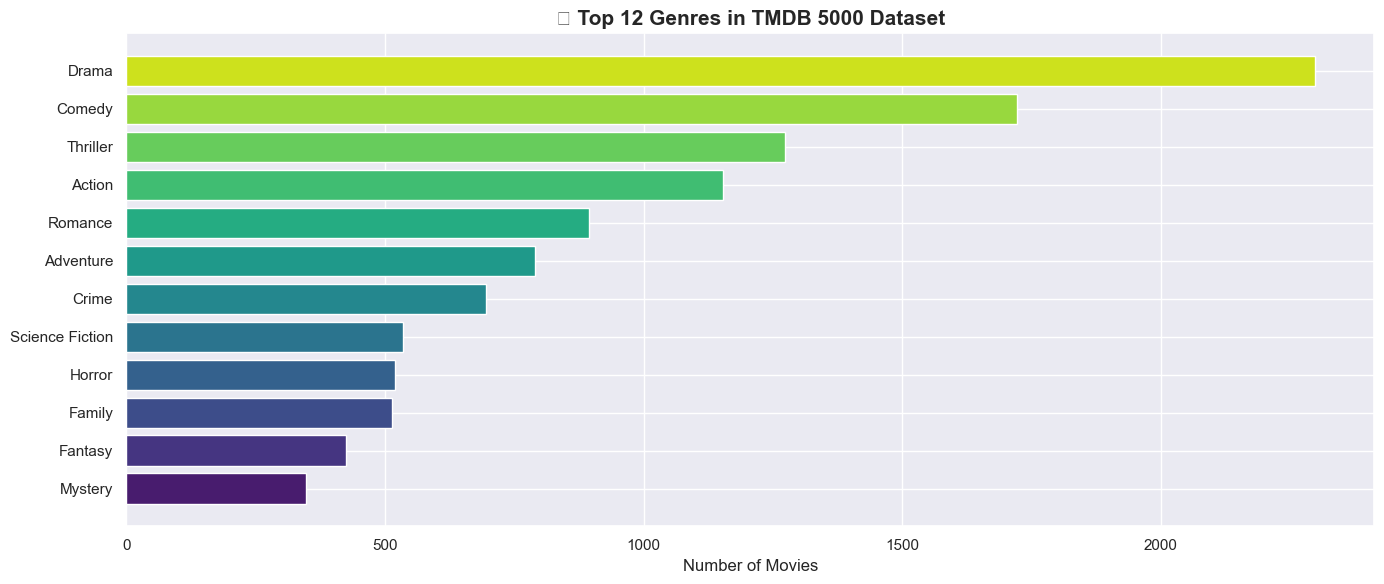

              Genre  Count
0             Drama   2297
1            Comedy   1722
2          Thriller   1274
3            Action   1154
4           Romance    894
5         Adventure    790
6             Crime    696
7   Science Fiction    535
8            Horror    519
9            Family    513
10          Fantasy    424
11          Mystery    348


In [17]:
# Flatten all genres into one list
all_genres = [g for sublist in df['genres_list'] for g in sublist]
genre_counts = Counter(all_genres)

# Convert to DataFrame for plotting
genre_df = pd.DataFrame(genre_counts.most_common(12),
                         columns=['Genre', 'Count'])

# Plot
plt.figure(figsize=(14, 6))
bars = plt.barh(genre_df['Genre'][::-1],
                genre_df['Count'][::-1],
                color=sns.color_palette("viridis", 12))
plt.xlabel("Number of Movies")
plt.title("🎬 Top 12 Genres in TMDB 5000 Dataset", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_genres.png', dpi=150)
plt.show()

print(genre_df)

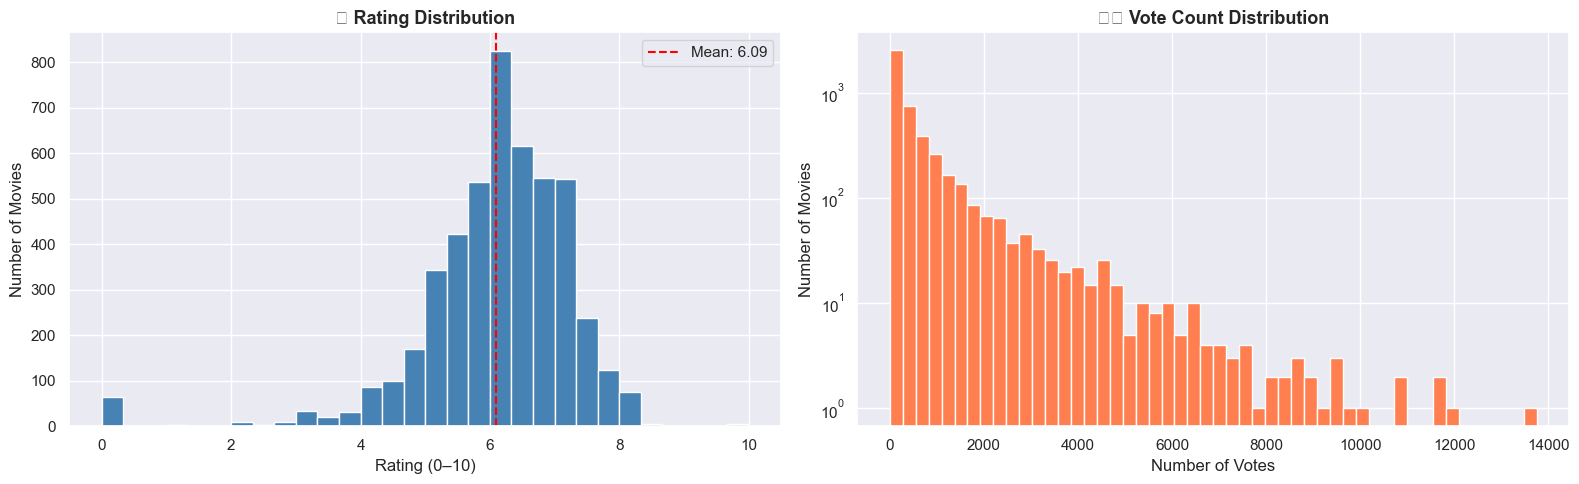

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1 — Rating histogram
axes[0].hist(df['vote_average'], bins=30, 
             color='steelblue', edgecolor='white')
axes[0].set_title('⭐ Rating Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating (0–10)')
axes[0].set_ylabel('Number of Movies')
axes[0].axvline(df['vote_average'].mean(), 
                color='red', linestyle='--', 
                label=f"Mean: {df['vote_average'].mean():.2f}")
axes[0].legend()

# Chart 2 — Vote count histogram (log scale)
axes[1].hist(df['vote_count'], bins=50, 
             color='coral', edgecolor='white')
axes[1].set_title('🗳️ Vote Count Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Votes')
axes[1].set_ylabel('Number of Movies')
axes[1].set_yscale('log')   # ← Log scale because it's heavily skewed

plt.tight_layout()
plt.savefig('eda_ratings.png', dpi=150)
plt.show()

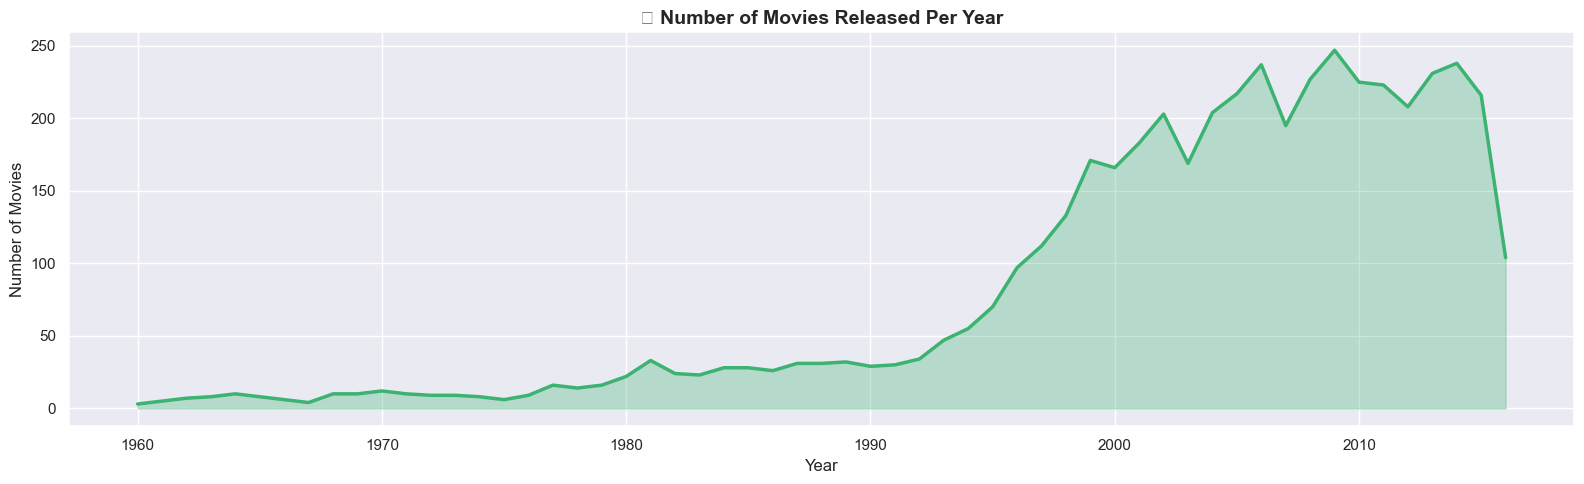

In [19]:
yearly = df.groupby('release_year')['title'].count().reset_index()
yearly.columns = ['Year', 'Count']
yearly = yearly.dropna().query("Year >= 1960 and Year <= 2016")

plt.figure(figsize=(16, 5))
plt.plot(yearly['Year'], yearly['Count'], 
         color='mediumseagreen', linewidth=2.5)
plt.fill_between(yearly['Year'], yearly['Count'], 
                 alpha=0.3, color='mediumseagreen')
plt.title('📅 Number of Movies Released Per Year', 
          fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('eda_yearly.png', dpi=150)
plt.show()

Movies with budget+revenue data: 3229 out of 4803


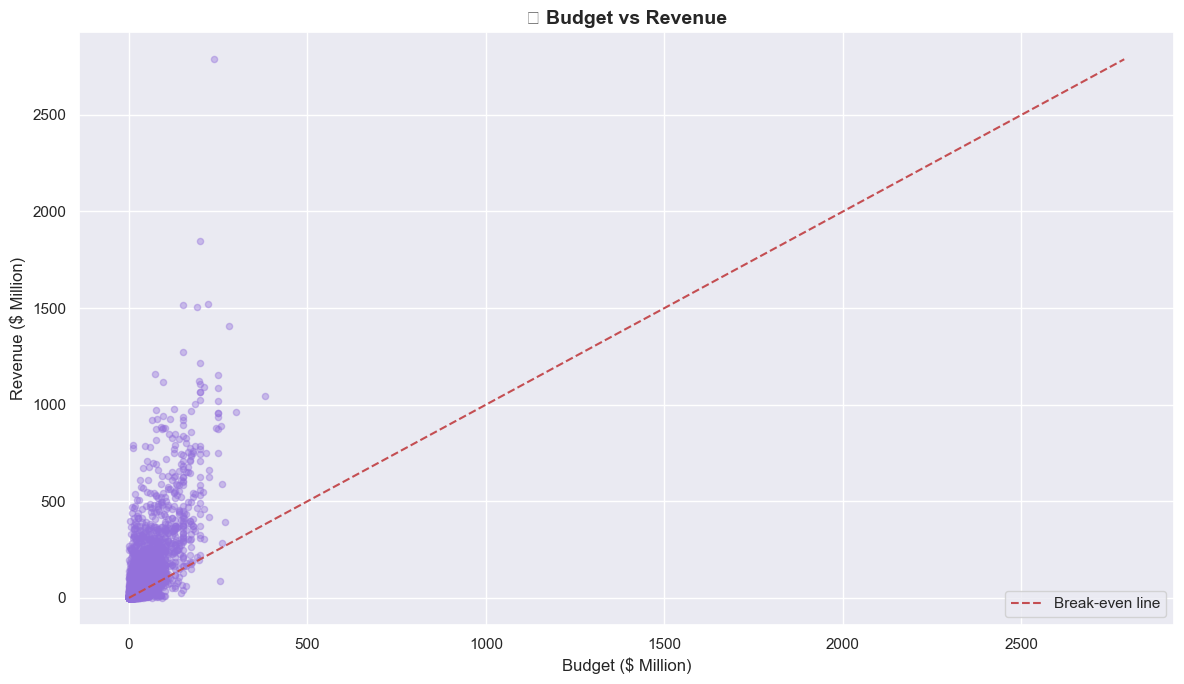


=== TOP 5 MOST PROFITABLE MOVIES ===
         Title  Budget($M)  Revenue($M)  Profit($M)
        Avatar       237.0  2787.965087 2550.965087
       Titanic       200.0  1845.034188 1645.034188
Jurassic World       150.0  1513.528810 1363.528810
     Furious 7       190.0  1506.249360 1316.249360
  The Avengers       220.0  1519.557910 1299.557910


In [20]:
# Create profit column
df['profit'] = df['revenue'] - df['budget']

# Filter only movies where both budget and revenue are recorded
df_money = df[(df['budget'] > 0) & (df['revenue'] > 0)].copy()

print(f"Movies with budget+revenue data: {len(df_money)} out of {len(df)}")

# Scatter plot
plt.figure(figsize=(12, 7))
plt.scatter(df_money['budget'] / 1e6,
            df_money['revenue'] / 1e6,
            alpha=0.4, color='mediumpurple', s=20)

# Add break-even line (revenue = budget)
max_val = max(df_money['budget'].max(), 
              df_money['revenue'].max()) / 1e6
plt.plot([0, max_val], [0, max_val], 
         'r--', linewidth=1.5, label='Break-even line')

plt.xlabel('Budget ($ Million)')
plt.ylabel('Revenue ($ Million)')
plt.title('💰 Budget vs Revenue', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('eda_budget_revenue.png', dpi=150)
plt.show()

# Most profitable movies
print("\n=== TOP 5 MOST PROFITABLE MOVIES ===")
top5 = df_money.nlargest(5, 'profit')[['title', 'budget', 'revenue', 'profit']]
top5[['budget','revenue','profit']] = top5[['budget','revenue','profit']] / 1e6
top5.columns = ['Title', 'Budget($M)', 'Revenue($M)', 'Profit($M)']
print(top5.to_string(index=False))

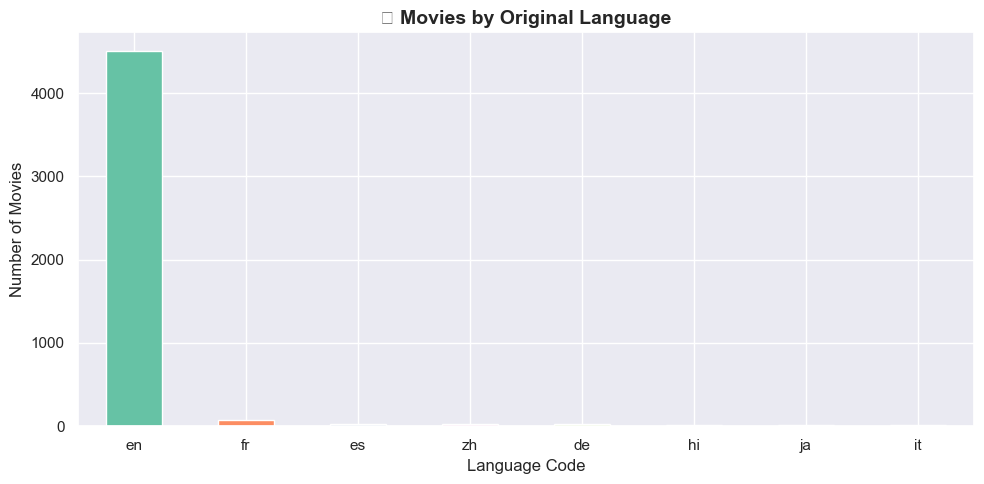

original_language
en    4505
fr      70
es      32
zh      27
de      27
hi      19
ja      16
it      14
Name: count, dtype: int64


In [21]:
lang_counts = df['original_language'].value_counts().head(8)

plt.figure(figsize=(10, 5))
lang_counts.plot(kind='bar', color=sns.color_palette("Set2", 8))
plt.title('🌍 Movies by Original Language', 
          fontsize=14, fontweight='bold')
plt.xlabel('Language Code')
plt.ylabel('Number of Movies')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('eda_language.png', dpi=150)
plt.show()

print(lang_counts)

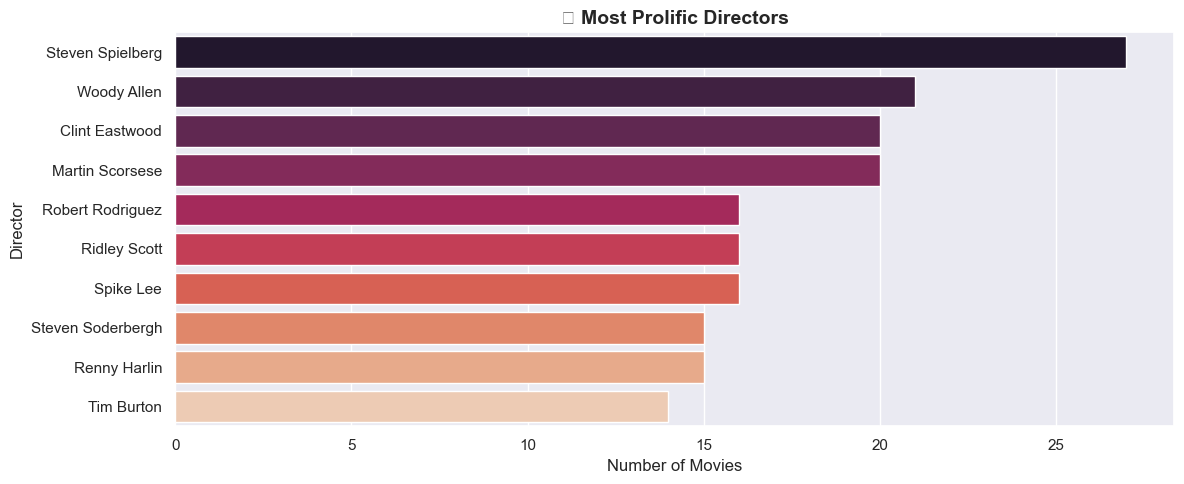

         Director  Movies
 Steven Spielberg      27
      Woody Allen      21
   Clint Eastwood      20
  Martin Scorsese      20
 Robert Rodriguez      16
     Ridley Scott      16
        Spike Lee      16
Steven Soderbergh      15
     Renny Harlin      15
       Tim Burton      14


In [22]:
top_directors = df['director'].value_counts().head(10).reset_index()
top_directors.columns = ['Director', 'Movies']

plt.figure(figsize=(12, 5))
sns.barplot(data=top_directors, x='Movies', y='Director',
            palette='rocket')
plt.title('🎥 Most Prolific Directors', fontsize=14, fontweight='bold')
plt.xlabel('Number of Movies')
plt.tight_layout()
plt.savefig('eda_directors.png', dpi=150)
plt.show()

print(top_directors.to_string(index=False))

In [23]:
# Summary you'll reference in your README later
summary = {
    'Total Movies'         : len(df),
    'Unique Genres'        : len(set(all_genres)),
    'Most Common Genre'    : genre_counts.most_common(1)[0][0],
    'Average Rating'       : round(df['vote_average'].mean(), 2),
    'Top Director'         : df['director'].value_counts().index[0],
    'English Movies %'     : round(
                              df[df['original_language']=='en'].shape[0] 
                              / len(df) * 100, 1),
    'Most Profitable Movie': df_money.nlargest(1, 'profit')['title'].values[0]
}

for k, v in summary.items():
    print(f"{k:30s}: {v}")

Total Movies                  : 4803
Unique Genres                 : 20
Most Common Genre             : Drama
Average Rating                : 6.09
Top Director                  : Steven Spielberg
English Movies %              : 93.8
Most Profitable Movie         : Avatar


In [24]:
df = pd.read_csv('tmdb_merged.csv')
print("Original shape:", df.shape)
print("\nNull values:\n", df.isnull().sum()[df.isnull().sum() > 0])

Original shape: (4803, 22)

Null values:
 homepage        3091
overview           3
release_date       1
runtime            2
tagline          844
dtype: int64


In [25]:
columns_to_keep = [
    'movie_id', 'title', 'overview',
    'genres', 'keywords', 'cast', 'crew',
    'vote_average', 'vote_count',
    'popularity', 'release_date'
]

df = df[columns_to_keep]

print("Shape after column selection:", df.shape)
print("Columns:", df.columns.tolist())

Shape after column selection: (4803, 11)
Columns: ['movie_id', 'title', 'overview', 'genres', 'keywords', 'cast', 'crew', 'vote_average', 'vote_count', 'popularity', 'release_date']


In [26]:
print("Nulls before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df['overview'] = df['overview'].fillna('')

df.dropna(subset=['release_date'], inplace=True)

df.reset_index(drop=True, inplace=True)

print("\nNulls after cleaning:", df.isnull().sum().sum())
print("Shape:", df.shape)

Nulls before cleaning:
overview        3
release_date    1
dtype: int64

Nulls after cleaning: 0
Shape: (4802, 11)


In [27]:
def parse_genres(text):
    try:
        items = ast.literal_eval(text)
        return [i['name'].replace(" ", "") for i in items]
    except:
        return []

df['genres'] = df['genres'].apply(parse_genres)

print("Sample genres:")
print(df['genres'][0])


Sample genres:
['Action', 'Adventure', 'Fantasy', 'ScienceFiction']


In [28]:
def parse_keywords(text):
    try:
        items = ast.literal_eval(text)
        return [i['name'].replace(" ", "") for i in items[:10]]
    except:
        return []

df['keywords'] = df['keywords'].apply(parse_keywords)

print("Sample keywords:")
print(df['keywords'][0])

Sample keywords:
['cultureclash', 'future', 'spacewar', 'spacecolony', 'society', 'spacetravel', 'futuristic', 'romance', 'space', 'alien']


In [29]:
def parse_cast(text):
    try:
        items = ast.literal_eval(text)
        return [i['name'].replace(" ", "") for i in items[:5]]
    except:
        return []

df['cast'] = df['cast'].apply(parse_cast)

print("Sample cast:")
print(df['cast'][0])

Sample cast:
['SamWorthington', 'ZoeSaldana', 'SigourneyWeaver', 'StephenLang', 'MichelleRodriguez']


In [30]:
def parse_director(text):
    try:
        items = ast.literal_eval(text)
        for person in items:
            if person['job'] == 'Director':
                return [person['name'].replace(" ", "")]
        return []
    except:
        return []

df['crew'] = df['crew'].apply(parse_director)

print("Sample crew:")
print(df['crew'][0])

Sample crew:
['JamesCameron']


In [31]:
C = df['vote_average'].mean()
m = df['vote_count'].quantile(0.70)

print(f"Average rating across all movies (C): {C:.2f}")
print(f"Minimum votes required (m): {m:.0f}")

Average rating across all movies (C): 6.09
Minimum votes required (m): 581


In [32]:
def weighted_rating(row, m=m, C=C):
    v = row['vote_count']
    R = row['vote_average']
    return (v / (v + m) * R) + (m / (v + m) * C)

df['weighted_rating'] = df.apply(weighted_rating, axis=1)

print("\nTop 5 by weighted rating:")
top5 = df.nlargest(5, 'weighted_rating')[
    ['title', 'vote_average', 'vote_count', 'weighted_rating']
]
print(top5.to_string(index=False))


Top 5 by weighted rating:
                   title  vote_average  vote_count  weighted_rating
The Shawshank Redemption           8.5        8205         8.340859
           The Godfather           8.4        5893         8.193001
              Fight Club           8.3        9413         8.171722
            Pulp Fiction           8.3        8428         8.157697
         The Dark Knight           8.2       12002         8.102733


In [33]:
df['release_year'] = pd.to_datetime(
    df['release_date'], errors='coerce'
).dt.year.astype('Int64')

df.drop(columns=['release_date'], inplace=True)

df.reset_index(drop=True, inplace=True)

print("Final shape:", df.shape)
print("Final columns:", df.columns.tolist())

Final shape: (4802, 12)
Final columns: ['movie_id', 'title', 'overview', 'genres', 'keywords', 'cast', 'crew', 'vote_average', 'vote_count', 'popularity', 'weighted_rating', 'release_year']


In [34]:
print("=== FINAL CHECK ===")
print("Shape:", df.shape)
print("Nulls:", df.isnull().sum().sum())
print()
print("Sample row:")
print("Title   :", df['title'][0])
print("Genres  :", df['genres'][0])
print("Keywords:", df['keywords'][0])
print("Cast    :", df['cast'][0])
print("Crew    :", df['crew'][0])
print("Rating  :", df['weighted_rating'][0])
df.to_csv('tmdb_preprocessed.csv', index=False)

=== FINAL CHECK ===
Shape: (4802, 12)
Nulls: 0

Sample row:
Title   : Avatar
Genres  : ['Action', 'Adventure', 'Fantasy', 'ScienceFiction']
Keywords: ['cultureclash', 'future', 'spacewar', 'spacecolony', 'society', 'spacetravel', 'futuristic', 'romance', 'space', 'alien']
Cast    : ['SamWorthington', 'ZoeSaldana', 'SigourneyWeaver', 'StephenLang', 'MichelleRodriguez']
Crew    : ['JamesCameron']
Rating  : 7.148072754665229


In [35]:
from nltk.stem import PorterStemmer
df = pd.read_csv('tmdb_preprocessed.csv')

print("Shape:", df.shape)
print("\nSample row:")
print(df[['title', 'genres', 'cast', 'crew']].iloc[0])

Shape: (4802, 12)

Sample row:
title                                                Avatar
genres    ['Action', 'Adventure', 'Fantasy', 'ScienceFic...
cast      ['SamWorthington', 'ZoeSaldana', 'SigourneyWea...
crew                                       ['JamesCameron']
Name: 0, dtype: object


In [36]:
import ast

def convert_to_list(text):
    try:
        return ast.literal_eval(text)
    except:
        return []

df['genres']   = df['genres'].apply(convert_to_list)
df['keywords'] = df['keywords'].apply(convert_to_list)
df['cast']     = df['cast'].apply(convert_to_list)
df['crew']     = df['crew'].apply(convert_to_list)

print("Genres sample :", df['genres'][0])
print("Cast sample   :", df['cast'][0])
print("Crew sample   :", df['crew'][0])

Genres sample : ['Action', 'Adventure', 'Fantasy', 'ScienceFiction']
Cast sample   : ['SamWorthington', 'ZoeSaldana', 'SigourneyWeaver', 'StephenLang', 'MichelleRodriguez']
Crew sample   : ['JamesCameron']


In [37]:
def clean_overview(text):
    if isinstance(text, str):
        return text.lower().split()
    return []

df['overview'] = df['overview'].apply(clean_overview)

print("Overview sample:", df['overview'][0][:8])

Overview sample: ['in', 'the', '22nd', 'century,', 'a', 'paraplegic', 'marine', 'is']


In [38]:
def create_tags(row):
    tags = (
        row['genres'] +
        row['keywords'] +
        row['cast'] +
        row['crew'] +
        row['overview']
    )
    return " ".join(tags)

df['tags'] = df.apply(create_tags, axis=1)

print("Tags sample:")
print(df['tags'][0][:200])

Tags sample:
Action Adventure Fantasy ScienceFiction cultureclash future spacewar spacecolony society spacetravel futuristic romance space alien SamWorthington ZoeSaldana SigourneyWeaver StephenLang MichelleRodrig


In [39]:
import nltk
nltk.download('punkt')

ps = PorterStemmer()

def stem_tags(text):
    words = text.split()
    stemmed = [ps.stem(word) for word in words]
    return " ".join(stemmed)

df['tags'] = df['tags'].apply(stem_tags)

print("After stemming:")
print(df['tags'][0][:200])

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rakes\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


After stemming:
action adventur fantasi sciencefict cultureclash futur spacewar spacecoloni societi spacetravel futurist romanc space alien samworthington zoesaldana sigourneyweav stephenlang michellerodriguez jamesc


In [40]:
df['tags'] = df['tags'].str.lower()

print("Sample final tags:")
print(df['tags'][0][:200])

Sample final tags:
action adventur fantasi sciencefict cultureclash futur spacewar spacecoloni societi spacetravel futurist romanc space alien samworthington zoesaldana sigourneyweav stephenlang michellerodriguez jamesc


In [41]:
final_df = df[['movie_id', 'title', 'tags', 
               'weighted_rating', 'popularity',
               'release_year', 'genres', 'cast', 'crew']].copy()

print("Final shape:", final_df.shape)
print("\nColumn check:")
print(final_df.columns.tolist())
print("\nSample:")
print(final_df[['title', 'tags']].iloc[0])

final_df.to_csv('tmdb_features.csv', index=False)
print("\n Saved as tmdb_features.csv")

Final shape: (4802, 9)

Column check:
['movie_id', 'title', 'tags', 'weighted_rating', 'popularity', 'release_year', 'genres', 'cast', 'crew']

Sample:
title                                               Avatar
tags     action adventur fantasi sciencefict culturecla...
Name: 0, dtype: object

 Saved as tmdb_features.csv


In [42]:
print("=== FINAL FEATURE CHECK ===")
print(f"Total movies     : {len(final_df)}")
print(f"Null tags        : {final_df['tags'].isnull().sum()}")
print(f"Empty tags       : {(final_df['tags'] == '').sum()}")
print(f"\nSample movie     : {final_df['title'][0]}")
print(f"Tags preview     : {final_df['tags'][0][:150]}")
print(f"Weighted rating  : {final_df['weighted_rating'][0]:.2f}")
print(f"Release year     : {final_df['release_year'][0]}")

=== FINAL FEATURE CHECK ===
Total movies     : 4802
Null tags        : 0
Empty tags       : 0

Sample movie     : Avatar
Tags preview     : action adventur fantasi sciencefict cultureclash futur spacewar spacecoloni societi spacetravel futurist romanc space alien samworthington zoesaldana 
Weighted rating  : 7.15
Release year     : 2009


In [43]:
import pandas as pd
import numpy as np
import ast
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

df = pd.read_csv('tmdb_features.csv')

print("Shape:", df.shape)
print("Sample tags:", df['tags'][0][:150])

Shape: (4802, 9)
Sample tags: action adventur fantasi sciencefict cultureclash futur spacewar spacecoloni societi spacetravel futurist romanc space alien samworthington zoesaldana 


In [44]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

tfidf_matrix = tfidf.fit_transform(df['tags'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Type:", type(tfidf_matrix))

TF-IDF matrix shape: (4802, 5000)
Type: <class 'scipy.sparse._csr.csr_matrix'>


In [45]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print("Similarity matrix shape:", cosine_sim.shape)
print("Sample similarity scores for Avatar:")
print(cosine_sim[0][:10])

Similarity matrix shape: (4802, 4802)
Sample similarity scores for Avatar:
[1.         0.02562143 0.01449669 0.04765057 0.10996197 0.0569032
 0.01939621 0.06327737 0.02101626 0.027692  ]


In [46]:
def recommend(movie_title, n=10):
    
    matches = df[df['title'].str.lower() == movie_title.lower()]
    
    if matches.empty:
        print(f" Movie '{movie_title}' not found!")
        search_term = movie_title[:4].lower()
        
        suggestions = df[
            df['title'].str.lower().str.contains(search_term)
        ]['title'].head(5)
        
        if not suggestions.empty:
            print("Did you mean one of these?")
            for i, title in enumerate(suggestions.tolist(), 1):
                print(f"  {i}. {title}")
        else:
            print("No similar titles found.")
        return
    
    movie_idx = matches.index[0]
    
    # Step B — Get similarity scores for this movie
    sim_scores = list(enumerate(cosine_sim[movie_idx]))
    
    # Step C — Sort by similarity score
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Step D — Remove the movie itself (score = 1.0)
    sim_scores = sim_scores[1:n+1]
    
    # Step E — Get movie indices
    movie_indices = [i[0] for i in sim_scores]
    
    # Step F — Return results
    results = df[['title', 'weighted_rating', 
                  'release_year']].iloc[movie_indices].copy()
    results['similarity_score'] = [round(i[1], 3) for i in sim_scores]
    results = results.reset_index(drop=True)
    results.index = results.index + 1
    
    print(f"\n Because you watched '{movie_title}', you might like:\n")
    print(results.to_string())
    return results

# Test 1 — Basic test
recommend("Avatar")


 Because you watched 'Avatar', you might like:

                          title  weighted_rating  release_year  similarity_score
1   Aliens vs Predator: Requiem         5.424897          2007             0.208
2                     Apollo 18         5.678003          2011             0.207
3                     Meet Dave         5.667320          2008             0.196
4                     Lifeforce         6.113532          1985             0.178
5       Star Trek Into Darkness         7.248147          2013             0.177
6                    Titan A.E.         6.165759          2000             0.176
7                        Aliens         7.454430          1986             0.175
8              The Book of Life         6.775291          2014             0.167
9                      Galaxina         6.018574          1980             0.166
10          Aliens in the Attic         5.858774          2009             0.165


,title,weighted_rating,release_year,similarity_score
1,Aliens vs Predator: Requiem,5.424897,2007,0.208
2,Apollo 18,5.678003,2011,0.207
3,Meet Dave,5.667320,2008,0.196
4,Lifeforce,6.113532,1985,0.178
5,Star Trek Into Darkness,7.248147,2013,0.177
6,Titan A.E.,6.165759,2000,0.176
7,Aliens,7.454430,1986,0.175
8,The Book of Life,6.775291,2014,0.167
9,Galaxina,6.018574,1980,0.166
10,Aliens in the Attic,5.858774,2009,0.165


In [47]:
recommend("Avatar")
recommend("The Dark Knight")
recommend("Titanic")
recommend("inception")
recommend("Avater")


 Because you watched 'Avatar', you might like:

                          title  weighted_rating  release_year  similarity_score
1   Aliens vs Predator: Requiem         5.424897          2007             0.208
2                     Apollo 18         5.678003          2011             0.207
3                     Meet Dave         5.667320          2008             0.196
4                     Lifeforce         6.113532          1985             0.178
5       Star Trek Into Darkness         7.248147          2013             0.177
6                    Titan A.E.         6.165759          2000             0.176
7                        Aliens         7.454430          1986             0.175
8              The Book of Life         6.775291          2014             0.167
9                      Galaxina         6.018574          1980             0.166
10          Aliens in the Attic         5.858774          2009             0.165

 Because you watched 'The Dark Knight', you might like:

  

In [48]:
import pickle

# Save the similarity matrix
with open('cosine_sim.pkl', 'wb') as f:
    pickle.dump(cosine_sim, f)

# Save the dataframe
with open('movie_df.pkl', 'wb') as f:
    pickle.dump(df, f)

print("cosine_sim.pkl saved!")
print("movie_df.pkl saved!")
print(f"Similarity matrix size: {cosine_sim.nbytes / 1024 / 1024:.1f} MB")

cosine_sim.pkl saved!
movie_df.pkl saved!
Similarity matrix size: 175.9 MB


In [49]:
# How many movies have at least one similar movie (score > 0.1)?
high_sim = (cosine_sim > 0.1).sum(axis=1)
print("Avg similar movies per movie:", high_sim.mean().round(1))
print("Min similar movies:", high_sim.min())
print("Max similar movies:", high_sim.max())

# Check distribution of similarity scores for Avatar
avatar_scores = cosine_sim[0]
avatar_scores_sorted = np.sort(avatar_scores)[::-1]

print(f"\nAvatar top 5 similarity scores:")
for i, score in enumerate(avatar_scores_sorted[1:6], 1):
    print(f"  Rank {i}: {score:.4f}")

Avg similar movies per movie: 44.3
Min similar movies: 2
Max similar movies: 309

Avatar top 5 similarity scores:
  Rank 1: 0.2080
  Rank 2: 0.2067
  Rank 3: 0.1962
  Rank 4: 0.1781
  Rank 5: 0.1769


In [50]:
import ast
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

df = pd.read_csv('tmdb_features.csv')

def convert_to_list(text):
    try:
        return ast.literal_eval(text)
    except:
        return []

df['genres'] = df['genres'].apply(convert_to_list)
df['cast']   = df['cast'].apply(convert_to_list)
df['crew']   = df['crew'].apply(convert_to_list)

print(" Ready for evaluation!")

 Ready for evaluation!


In [51]:
def get_recommendations_indices(movie_idx, n=10):
    sim_scores    = list(enumerate(cosine_sim[movie_idx]))
    sim_scores    = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores    = sim_scores[1:n+1]
    movie_indices = [i[0] for i in sim_scores]
    return movie_indices


def precision_at_k(movie_title, k=10):
    
    # Find the movie in dataframe
    matches = df[df['title'].str.lower() == movie_title.lower()]
    if matches.empty:
        print(f"Movie '{movie_title}' not found!")
        return 0
    
    movie_idx = matches.index[0]
    
    # Get this movie's genres
    source_genres = set(df.loc[movie_idx, 'genres'])
    
    # Get top K recommendations
    rec_indices = get_recommendations_indices(movie_idx, n=k)
    
    # Count how many recommended movies share at least 1 genre
    relevant_count = 0
    for idx in rec_indices:
        rec_genres    = set(df.loc[idx, 'genres'])
        shared_genres = source_genres & rec_genres
        if len(shared_genres) > 0:
            relevant_count += 1
    
    precision = relevant_count / k
    return precision


def recall_at_k(movie_title, k=10):
    
    matches = df[df['title'].str.lower() == movie_title.lower()]
    if matches.empty:
        return 0
    
    movie_idx     = matches.index[0]
    source_genres = set(df.loc[movie_idx, 'genres'])
    
    # Count ALL movies in dataset that share at least 1 genre
    total_relevant = 0
    for idx in df.index:
        if idx == movie_idx:
            continue
        rec_genres    = set(df.loc[idx, 'genres'])
        shared_genres = source_genres & rec_genres
        if len(shared_genres) > 0:
            total_relevant += 1
    
    # Get top K recommendations
    rec_indices = get_recommendations_indices(movie_idx, n=k)
    
    # Count relevant movies in top K
    relevant_count = 0
    for idx in rec_indices:
        rec_genres    = set(df.loc[idx, 'genres'])
        shared_genres = source_genres & rec_genres
        if len(shared_genres) > 0:
            relevant_count += 1
    
    if total_relevant == 0:
        return 0
    
    recall = relevant_count / total_relevant
    return recall

print(" Evaluation functions ready!")

 Evaluation functions ready!


In [52]:
test_movies = ["Avatar", "The Dark Knight", "Titanic", "Inception"]

print("="*60)
print(f"{'Movie':<30} {'P@5':>6} {'P@10':>6} {'R@10':>7}")
print("="*60)

for movie in test_movies:
    p5  = precision_at_k(movie, k=5)
    p10 = precision_at_k(movie, k=10)
    r10 = recall_at_k(movie, k=10)
    print(f"{movie:<30} {p5:>6.2f} {p10:>6.2f} {r10:>8.4f}")

print("="*60)

Movie                             P@5   P@10    R@10
Avatar                           1.00   1.00   0.0055
The Dark Knight                  1.00   1.00   0.0028
Titanic                          0.60   0.40   0.0012
Inception                        0.60   0.80   0.0034


In [53]:
def evaluate_model(sample_size=100):
    
    # Randomly sample movies that have genres
    movies_with_genres = df[df['genres'].apply(len) > 0]
    sample = movies_with_genres.sample(
                n=min(sample_size, len(movies_with_genres)),
                random_state=42
             )
    
    p5_scores  = []
    p10_scores = []
    r10_scores = []
    
    for _, row in sample.iterrows():
        title = row['title']
        p5_scores.append(precision_at_k(title, k=5))
        p10_scores.append(precision_at_k(title, k=10))
        r10_scores.append(recall_at_k(title, k=10))
    
    print("\n MODEL EVALUATION RESULTS")
    print("="*40)
    print(f"Movies evaluated  : {len(sample)}")
    print(f"Avg Precision@5   : {np.mean(p5_scores):.4f}")
    print(f"Avg Precision@10  : {np.mean(p10_scores):.4f}")
    print(f"Avg Recall@10     : {np.mean(r10_scores):.6f}")
    print(f"Best P@10 movie   : {sample.iloc[np.argmax(p10_scores)]['title']}")
    print(f"Worst P@10 movie  : {sample.iloc[np.argmin(p10_scores)]['title']}")
    print("="*40)
    
    return p5_scores, p10_scores, r10_scores

p5_scores, p10_scores, r10_scores = evaluate_model(sample_size=100)


 MODEL EVALUATION RESULTS
Movies evaluated  : 100
Avg Precision@5   : 0.7660
Avg Precision@10  : 0.7650
Avg Recall@10     : 0.003588
Best P@10 movie   : X-Men: The Last Stand
Worst P@10 movie  : Chocolate: Deep Dark Secrets


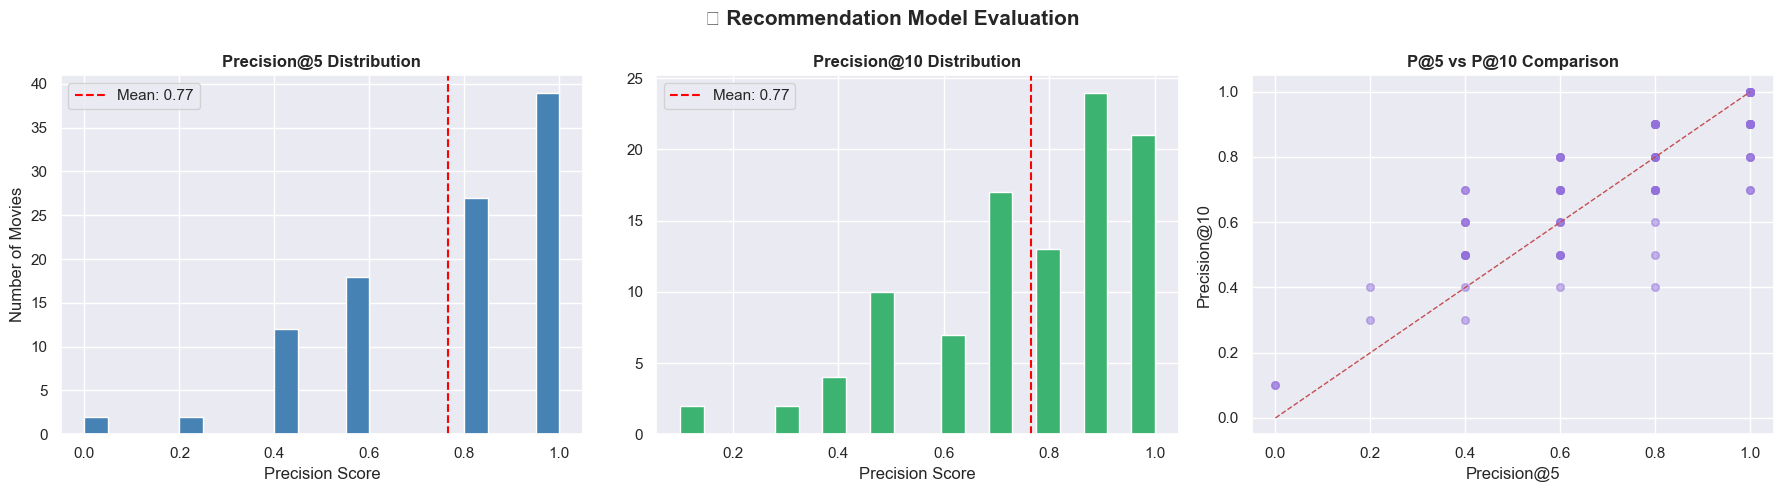

In [54]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1 — Precision@5 distribution
axes[0].hist(p5_scores, bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(p5_scores), color='red',
                linestyle='--',
                label=f'Mean: {np.mean(p5_scores):.2f}')
axes[0].set_title('Precision@5 Distribution', fontweight='bold')
axes[0].set_xlabel('Precision Score')
axes[0].set_ylabel('Number of Movies')
axes[0].legend()

# Chart 2 — Precision@10 distribution
axes[1].hist(p10_scores, bins=20, color='mediumseagreen', edgecolor='white')
axes[1].axvline(np.mean(p10_scores), color='red',
                linestyle='--',
                label=f'Mean: {np.mean(p10_scores):.2f}')
axes[1].set_title('Precision@10 Distribution', fontweight='bold')
axes[1].set_xlabel('Precision Score')
axes[1].legend()

# Chart 3 — P@5 vs P@10 scatter
axes[2].scatter(p5_scores, p10_scores,
                alpha=0.5, color='mediumpurple', s=30)
axes[2].plot([0,1], [0,1], 'r--', linewidth=1)
axes[2].set_title('P@5 vs P@10 Comparison', fontweight='bold')
axes[2].set_xlabel('Precision@5')
axes[2].set_ylabel('Precision@10')

plt.suptitle('📊 Recommendation Model Evaluation',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=150)
plt.show()

In [55]:
avg_p10 = np.mean(p10_scores)

print("\n WHAT YOUR SCORES MEAN:")
print("="*50)

if avg_p10 >= 0.80:
    quality = "🟢 Excellent"
    comment = "Model is working very well!"
elif avg_p10 >= 0.60:
    quality = "🟡 Good"
    comment = "Solid model — room to improve"
elif avg_p10 >= 0.40:
    quality = "🟠 Fair"
    comment = "Working but needs improvement"
else:
    quality = "🔴 Needs Work"
    comment = "Consider adding more features"

print(f"Your Avg Precision@10 : {avg_p10:.2f}")
print(f"Quality               : {quality}")
print(f"Comment               : {comment}")
print()
print("Context:")
print("  Random recommender would score  : ~0.15")
print("  Good content-based model scores : 0.60-0.80")
print("  Netflix-level model scores      : 0.85+")
print()
print("How to improve:")
print("  - Add more overview text weight")
print("  - Include runtime similarity")
print("  - Add release decade as a feature")
print("  - Phase 2 will significantly improve this!")


 WHAT YOUR SCORES MEAN:
Your Avg Precision@10 : 0.77
Quality               : 🟡 Good
Comment               : Solid model — room to improve

Context:
  Random recommender would score  : ~0.15
  Good content-based model scores : 0.60-0.80
  Netflix-level model scores      : 0.85+

How to improve:
  - Add more overview text weight
  - Include runtime similarity
  - Add release decade as a feature
  - Phase 2 will significantly improve this!
